In [ ]:
# Multi-target: shared colors
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

tp.plot_graph(
    gt1, var_names=names1, fig_ax=(fig, axes[0]),
    target_node=[names1[0], names1[3]],
    edge_color="#CCCCCC",
)
axes[0].set_title(f"Targets: {names1[0]}, {names1[3]} (shared colors)")

# Multi-target: per-target colors
tp.plot_graph(
    gt1, var_names=names1, fig_ax=(fig, axes[1]),
    target_node=[names1[0], names1[3]],
    target_node_color=["#4CAF50", "#E91E63"],
    target_in_color=["#2196F3", "#00BCD4"],
    target_out_color=["#FF9800", "#FFC107"],
    target_between_color="#9C27B0",
    edge_color="#CCCCCC",
)
axes[1].set_title(f"Targets: {names1[0]}, {names1[3]} (per-target colors)")

plt.tight_layout()
plt.show()

# Visualization Guide

Comprehensive guide to causal-ts visualization: graph plots, time-series graphs, comparison plots, p-value diagnostics, lag metrics, custom edge colors, target node highlighting, subgraph extraction, and CEDAR-specific plots.

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import causalts.plotting as tp
from causalts.plotting import extract_subgraph
from causalts.synthetic_data.synthetic_datasets import ex1_nl, ex3

## 1. Setup: Generate Data & Run Discovery

We use `ex1_nl` (5-variable nonlinear) and `ex3` (11-variable cascade) from the built-in datasets, then run CDNOTS to get a discovered graph with p-values.

In [11]:
data1 = ex1_nl(T=500, seed=42)
df1, gt1, names1 = data1["df"], data1["ground_truth"], list(data1["df"].columns)
print(f"ex1_nl: {data1['name']}, d={len(names1)}, T={len(df1)}, max_lag={data1['max_lag']}")

data3 = ex3(T=500, seed=42)
df3, gt3, names3 = data3["df"], data3["ground_truth"], list(data3["df"].columns)
print(f"ex3: {data3['name']}, d={len(names3)}, T={len(df3)}, max_lag={data3['max_lag']}")

ex1_nl: 5-Node Nonlinear System, d=5, T=500, max_lag=3
ex3: Cascade Network (11-Node), d=11, T=500, max_lag=3


In [12]:
from causalts import run_cdnots_plus
from causalts.ci_tests import RCOTGPU

# ex1_nl has nonlinear dependencies (x^2 terms) — use RCOTGPU which
# handles nonlinearity well and is fast (Random Fourier Features).
ci_test = RCOTGPU(df1.values, num_f=100, num_f2=10)
result = run_cdnots_plus(
    df1, ci_test, num_lags=data1["max_lag"],
    alpha=0.05, include_C=False, verbose=0,
    return_pvals=True,
)
discovered = result.cg_tig
print(f"Discovered graph shape: {discovered.shape}")
print(f"P-value matrix shape: {result.pvalue_matrix.shape}")

Discovered graph shape: (5, 5, 4)
P-value matrix shape: (5, 5, 4)


## 2. Basic `plot_graph`

The core network visualization. Variables are nodes; straight edges are contemporaneous, curved edges are lagged.

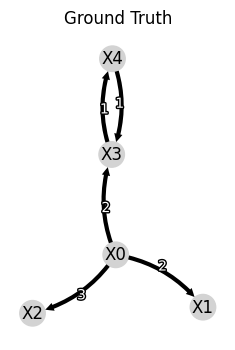

In [13]:
tp.plot_graph(gt1, var_names=names1, figsize=(4, 4), title="Ground Truth");

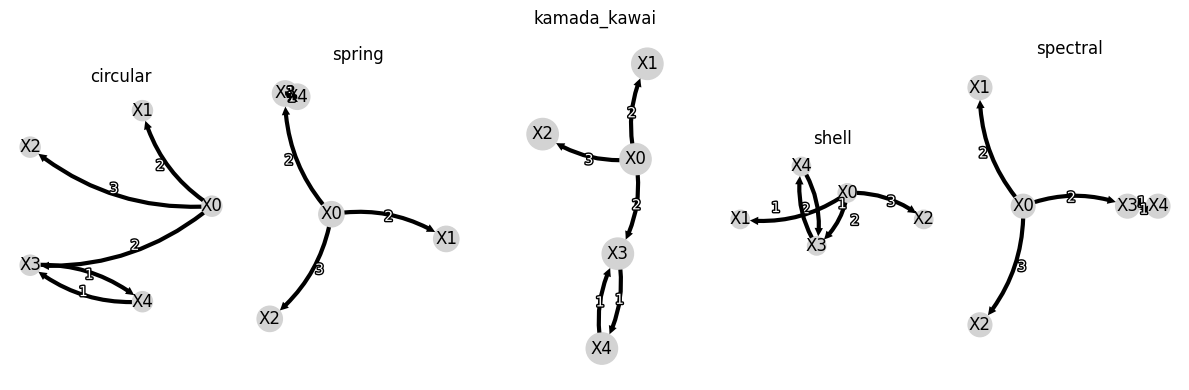

In [14]:
# Built-in Networkx layout algorithms
layouts = ["circular", "spring", "kamada_kawai", "shell", "spectral"]
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for ax, layout in zip(axes.flat, layouts):
    tp.plot_graph(
        gt1, var_names=names1, fig_ax=(fig, ax),
        node_layout=layout, node_size=0.2,
        arrow_linewidth=3, show_colorbar=False,
    )
    ax.set_title(layout)
plt.tight_layout()
plt.show()

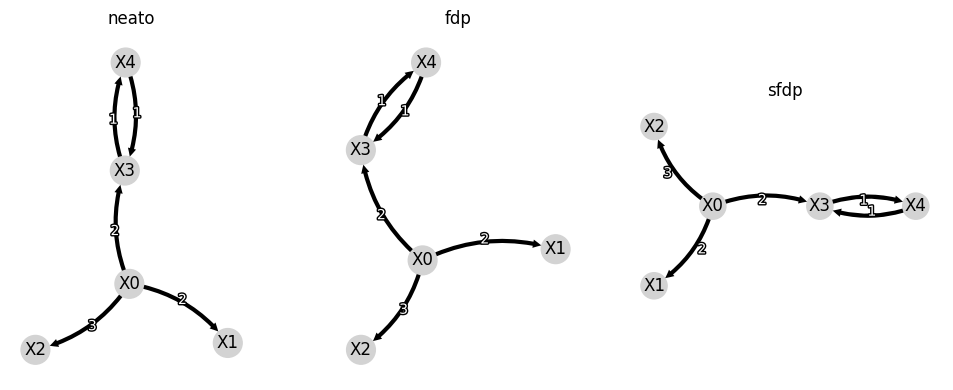

In [15]:
# Graphviz layouts (requires: pip install pygraphviz; brew install graphviz)
# These produce higher-quality layouts but need system-level graphviz.
# Falls back to 'circular' if pygraphviz is not installed.
import shutil

graphviz_layouts = ["neato", "fdp", "sfdp"]

if shutil.which("neato"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    for ax, layout in zip(axes, graphviz_layouts):
        tp.plot_graph(
            gt1, var_names=names1, fig_ax=(fig, ax),
            node_layout=layout, node_size=0.2,
            arrow_linewidth=3, show_colorbar=False,
        )
        ax.set_title(layout)
    plt.tight_layout()
    plt.show()
else:
    print("Graphviz not found — skipping neato/fdp/sfdp layouts.")
    print("Install with: brew install graphviz && pip install pygraphviz")

### Position reuse with `return_pos`

Compute positions once and reuse across plots for consistent layout.

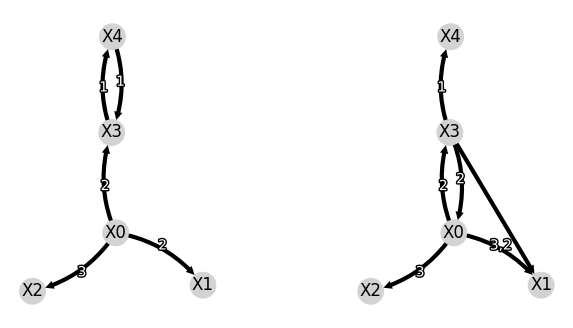

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
_, _, pos = tp.plot_graph(
    gt1, var_names=names1, node_layout="neato", fig_ax=(fig, axes[0]),
    show_colorbar=False, return_pos=True, title="Ground truth (spring)"
)

tp.plot_graph(
    discovered, var_names=names1, fig_ax=(fig, axes[1]),
    node_pos=pos, show_colorbar=False, title="Discovered (spring)"
);


### Convenience method: `result.plot()`

The `CdnotsResult` object has a bound `.plot()` method that wraps `plot_graph` and auto-handles C node labels.

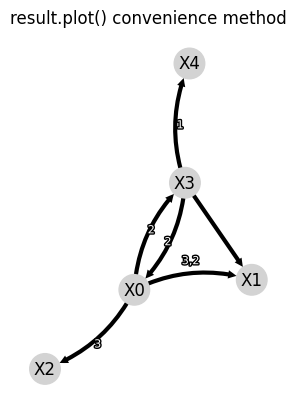

In [17]:
result.plot(
    var_names=names1, node_layout="neato",
    node_size=0.2, show_colorbar=False,
    arrow_linewidth=3, link_label_fontsize=8,
    title="result.plot() convenience method",
);

## 3. `plot_time_series_graph`

Time-unrolled DAG: variables on rows, time on columns. Lagged edges are drawn as curved arrows across time steps.

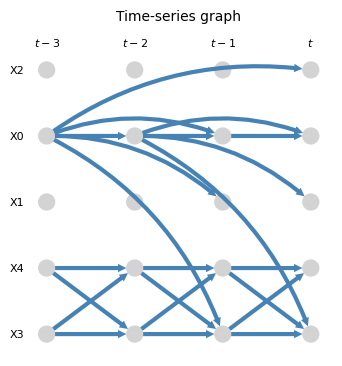

In [18]:
tp.plot_time_series_graph(
    gt1, var_names=names1,
    arrow_linewidth=3, node_size=0.06, figsize=(10, 4),
    title="Time-series graph",
    edge_color='steelblue', node_label_size=8,
    order=[1,2,0,4,3] # custom node order (optional)
)
plt.show()

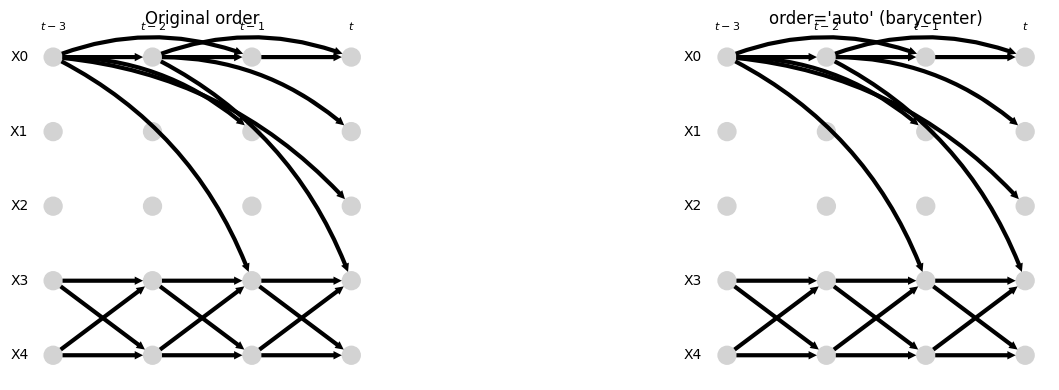

In [19]:
# order='auto' uses barycenter heuristic to reduce edge crossings
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
tp.plot_time_series_graph(
    gt1, var_names=names1,
    arrow_linewidth=3, node_size=0.06,
    fig_ax=(fig, axes[0]),
)
axes[0].set_title("Original order")
tp.plot_time_series_graph(
    gt1, var_names=names1,
    arrow_linewidth=3, node_size=0.06,
    order="auto", fig_ax=(fig, axes[1]),
)
axes[1].set_title("order='auto' (barycenter)")
plt.tight_layout()
plt.show()

## 4. Custom Edge Color

Use `edge_color` to change the default edge color (previously hardcoded to black). Works when `val_matrix` is not provided.

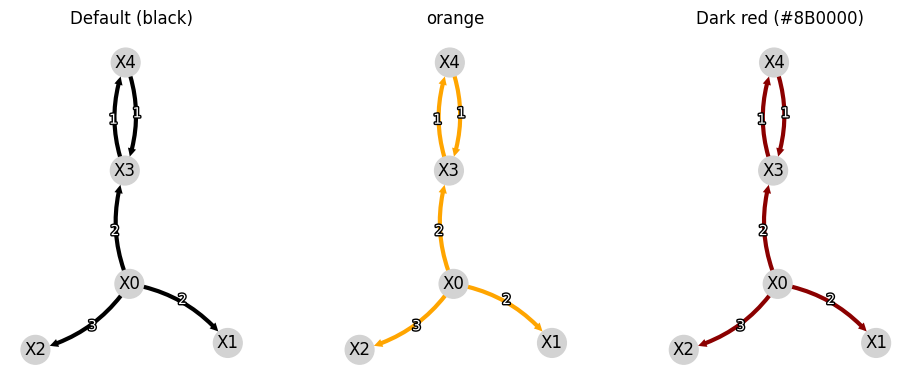

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

colors = ["black", "orange", "#8B0000"]
labels = ["Default (black)", "orange", "Dark red (#8B0000)"]

for ax, color, label in zip(axes, colors, labels):
    tp.plot_graph(
        gt1, var_names=names1, fig_ax=(fig, ax),
        edge_color=color, show_colorbar=False,
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 5. Target Node Highlighting

Highlight one or more variables to distinguish **incoming** (causes) and **outgoing** (effects) edges. Useful for understanding causal neighborhoods in large graphs.

Parameters:
- `target_node` — variable name, index, **or list** of names/indices for multi-target
- `target_in_color` — edges INTO target(s) (default: blue `#2196F3`). Pass a list for per-target colors.
- `target_out_color` — edges OUT OF target(s) (default: orange `#FF9800`). Pass a list for per-target colors.
- `target_node_color` — fill color for target node(s) (default: green `#4CAF50`). Pass a list for per-target colors.
- `target_between_color` — edges connecting two target nodes (default: purple `#9C27B0`)
- `edge_color` — non-target edges (default: black)

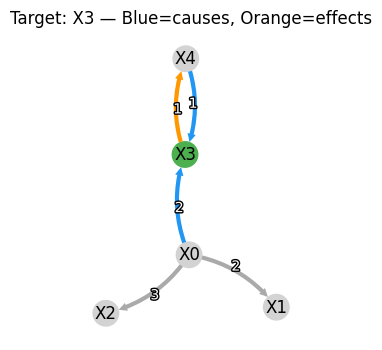

In [21]:
tp.plot_graph(
    gt1, var_names=names1,
    target_node=names1[3],
    target_in_color="#2196F3",
    target_out_color="#FF9800",
    target_node_color="#4CAF50",
    edge_color="#AAAAAA",
    figsize=(4, 4),
    title=f"Target: {names1[3]} — Blue=causes, Orange=effects",
);


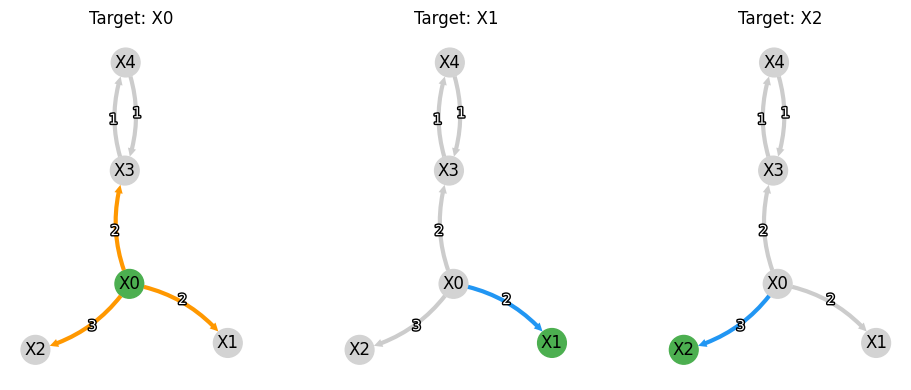

In [22]:
# Compare different target nodes
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, target in zip(axes, names1[:3]):
    tp.plot_graph(
        gt1, var_names=names1, fig_ax=(fig, ax),
        target_node=target, edge_color="#CCCCCC",
    )
    ax.set_title(f"Target: {target}")
plt.tight_layout()
plt.show()

### Multi-target highlighting

Pass a list to `target_node` to highlight multiple variables simultaneously. Edges between targets use `target_between_color`.

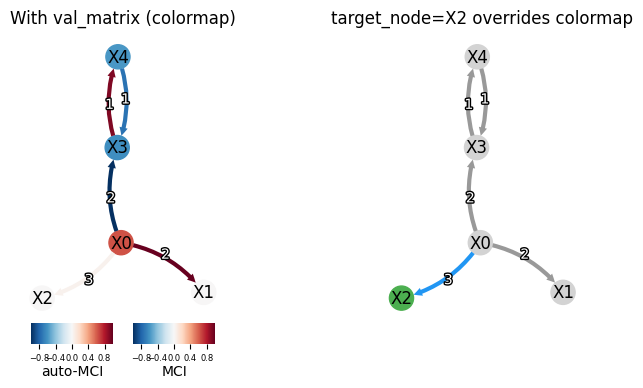

In [23]:
# Target highlighting overrides val_matrix colormap
rng = np.random.default_rng(0)
val = rng.standard_normal(gt1.shape) * gt1

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

tp.plot_graph(gt1, val_matrix=val, var_names=names1, fig_ax=(fig, axes[0]))
axes[0].set_title("With val_matrix (colormap)")

tp.plot_graph(
    gt1, val_matrix=val, var_names=names1,
    fig_ax=(fig, axes[1]),
    target_node=names1[2], edge_color="#999999",
)
axes[1].set_title(f"target_node={names1[2]} overrides colormap")

plt.tight_layout()
plt.show()

## 6. Subgraph Extraction

`extract_subgraph()` extracts the causal neighborhood around a target variable at configurable depth:
- `depth=1` — direct parents and children
- `depth=2` — parents/children of parents/children
- `direction="parents"` / `"children"` — restrict to ancestors or descendants

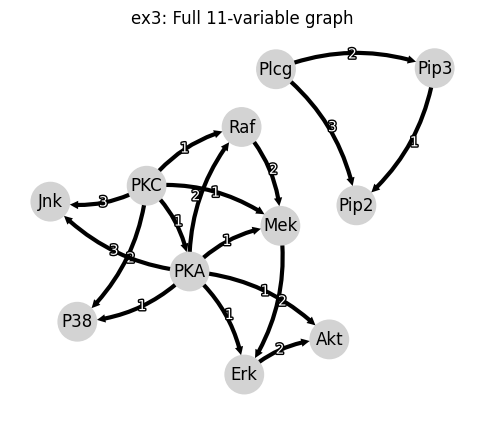

In [24]:
# Full 11-variable cascade network
tp.plot_graph(gt3, var_names=names3, figsize=(6, 6), show_colorbar=False)
plt.title(f"ex3: Full {len(names3)}-variable graph")
plt.show()

Target: Mek
Depth-1: ['PKC', 'PKA', 'Raf', 'Mek', 'Erk'] (5 vars)
Depth-2: ['PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt'] (8 vars)


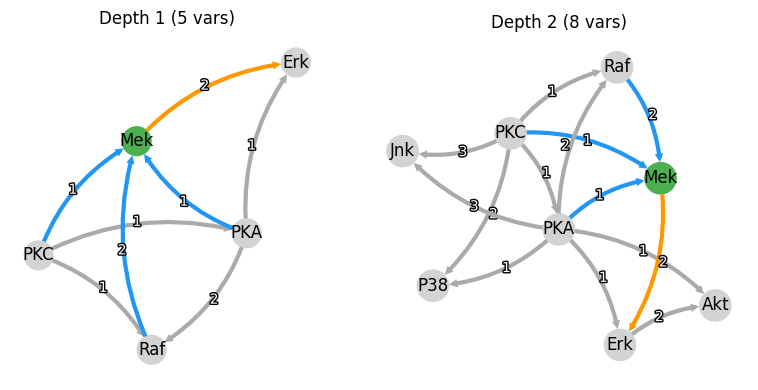

In [25]:
# We pick a variable with both parents and children for best demonstration
target_var = "Mek"

sub1, idx1, sub_names1 = extract_subgraph(gt3, target=target_var, depth=1, var_names=names3)
sub2, idx2, sub_names2 = extract_subgraph(gt3, target=target_var, depth=2, var_names=names3)
print(f"Target: {target_var}")
print(f"Depth-1: {sub_names1} ({len(sub_names1)} vars)")
print(f"Depth-2: {sub_names2} ({len(sub_names2)} vars)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
tp.plot_graph(
    sub1, var_names=sub_names1, fig_ax=(fig, axes[0]),
    target_node=target_var, edge_color="#AAAAAA",
)
axes[0].set_title(f"Depth 1 ({len(sub_names1)} vars)")
tp.plot_graph(
    sub2, var_names=sub_names2, fig_ax=(fig, axes[1]),
    target_node=target_var, edge_color="#AAAAAA",
)
axes[1].set_title(f"Depth 2 ({len(sub_names2)} vars)")
plt.tight_layout()
plt.show()

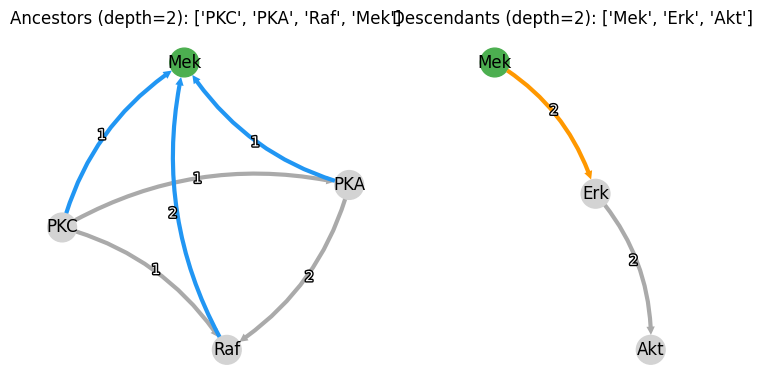

In [26]:
# Direction filtering: ancestors vs descendants
sub_p, _, names_p = extract_subgraph(
    gt3, target=target_var, depth=2, var_names=names3, direction="parents",
)
sub_c, _, names_c = extract_subgraph(
    gt3, target=target_var, depth=2, var_names=names3, direction="children",
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
tp.plot_graph(
    sub_p, var_names=names_p, fig_ax=(fig, axes[0]),
    target_node=target_var, edge_color="#AAAAAA",
)
axes[0].set_title(f"Ancestors (depth=2): {names_p}")
tp.plot_graph(
    sub_c, var_names=names_c, fig_ax=(fig, axes[1]),
    target_node=target_var, edge_color="#AAAAAA",
)
axes[1].set_title(f"Descendants (depth=2): {names_c}")
plt.tight_layout()
plt.show()

## 7. `compare_graphs` — TP / FP / FN Overlay

Overlays discovered vs ground truth with color-coded edges: TP (green), FP (orange), FN (red dashed).

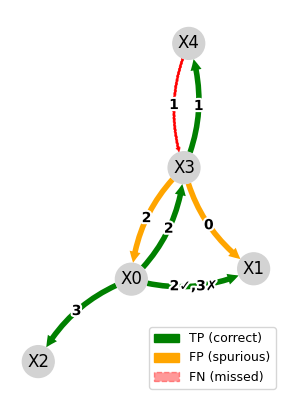

In [27]:
tp.compare_graphs(
    gt1, discovered, var_names=names1,
    figsize=(5, 5), show_legend=True, legend_loc="lower right", #set to None for auto placement of legend box
    arrow_linewidth=4, link_label_fontsize=10,
)
plt.show()

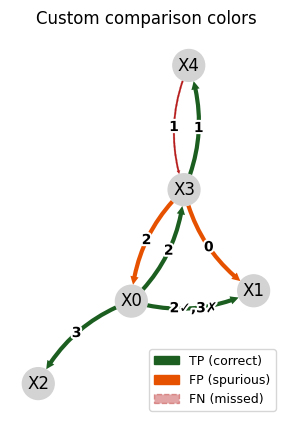

In [28]:
# Custom comparison colors
tp.compare_graphs(
    gt1, discovered, var_names=names1,
    figsize=(5, 5),
    tp_color="#1B5E20", fp_color="#E65100", fn_color="#B71C1C",
    fn_style="dotted",
    show_legend=True, legend_loc="lower right",
)
plt.title("Custom comparison colors")
plt.show()

## 8. `plot_metrics_summary` — Evaluation Bar Chart

Horizontal bar chart of Precision, Recall, F1, and SHD. Supports `level='lag'` (default) and `level='pair'`.

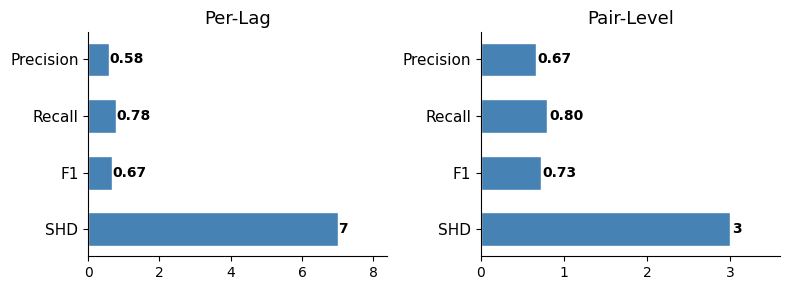

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
tp.plot_metrics_summary(
    gt1, discovered, title="Per-Lag", fig_ax=(fig, axes[0]),
)
tp.plot_metrics_summary(
    gt1, discovered, level="pair", title="Pair-Level", fig_ax=(fig, axes[1]),
)
plt.tight_layout()
plt.show()

## 9. `plot_lag_metrics` — Per-Lag Heatmap

Heatmap of precision / recall / F1 broken down by lag.

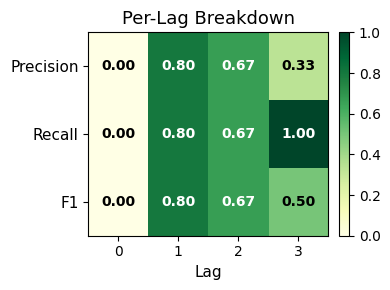

In [30]:
tp.plot_lag_metrics(
    gt1, discovered,
    title="Per-Lag Breakdown", figsize=(4,3),
)
plt.tight_layout()
plt.show()

## 10. `plot_pvalue_distribution` — P-Value Diagnostics

Histogram of p-values split by edge type. Two modes:
- **All tested pairs**: true edges (green) vs non-edges (grey)
- **Discovered edges only**: TP (green) vs FP (grey) — pass `graph_discovered`

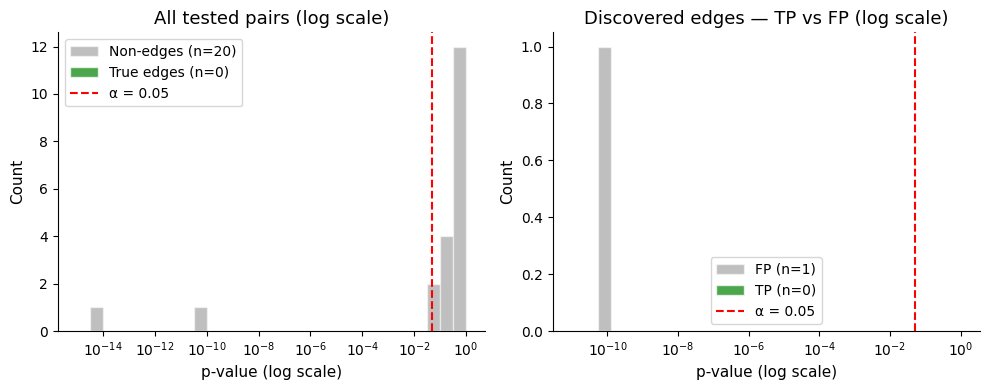

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# log_scale=True spreads out the near-zero p-values so the separation
# between true edges and non-edges is visible
tp.plot_pvalue_distribution(
    result.pvalue_matrix, gt1, alpha_line=0.05,
    log_scale=True,
    title="All tested pairs (log scale)", fig_ax=(fig, axes[0]),
)

tp.plot_pvalue_distribution(
    result.pvalue_matrix, gt1, graph_discovered=discovered,
    alpha_line=0.05, log_scale=True,
    title="Discovered edges — TP vs FP (log scale)",
    fig_ax=(fig, axes[1]),
)
plt.tight_layout()
plt.show()

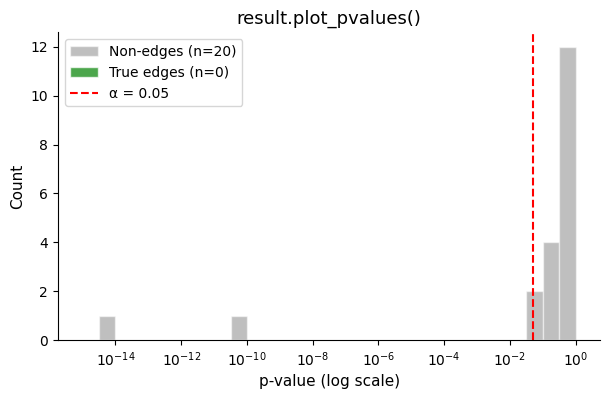

In [32]:
# Convenience method on the result object (also supports log_scale)
result.plot_pvalues(gt1, alpha_line=0.05, log_scale=True, title="result.plot_pvalues()")
plt.show()

## 11. Combining Features: Discovery + Extract + Highlight + Compare

Full pipeline: extract subgraph around a variable of interest, then compare discovered vs ground truth with target highlighting.

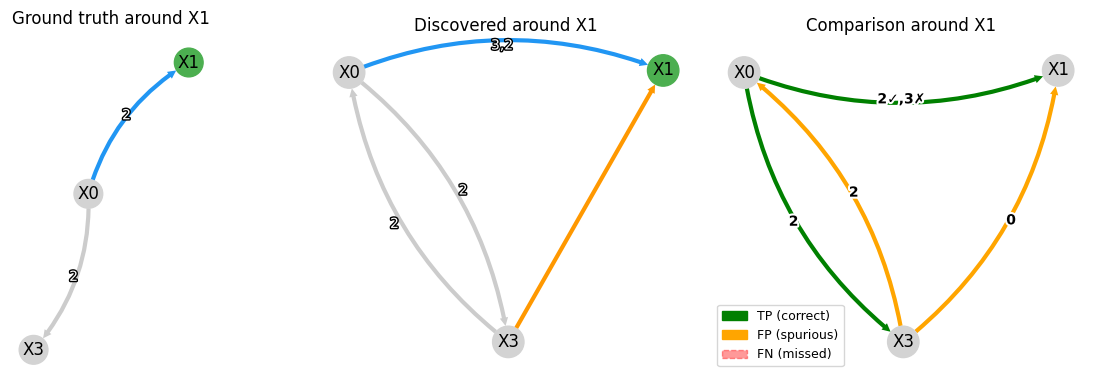

In [34]:
focus_var = names1[1]
sub_disc, idx_disc, names_disc = extract_subgraph(
    discovered, target=focus_var, depth=1, var_names=names1,
)
sub_gt = gt1[np.ix_(idx_disc, idx_disc, range(gt1.shape[2]))]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

tp.plot_graph(
    sub_gt, var_names=names_disc, fig_ax=(fig, axes[0]),
    target_node=focus_var, edge_color="#CCCCCC",
)
axes[0].set_title(f"Ground truth around {focus_var}")

tp.plot_graph(
    sub_disc, var_names=names_disc, fig_ax=(fig, axes[1]),
    target_node=focus_var, edge_color="#CCCCCC",
)
axes[1].set_title(f"Discovered around {focus_var}")

tp.compare_graphs(
    sub_gt, sub_disc, var_names=names_disc,
    fig_ax=(fig, axes[2]), show_legend=True,
    legend_loc="lower left",
    arrow_linewidth=3,
)
axes[2].set_title(f"Comparison around {focus_var}")

plt.tight_layout()
plt.show()

## 12. CEDAR Plots

`CedarResult` (returned by `run_cedar`) has built-in visualization methods:
- `.plot()` — causal graph (wraps `plot_graph`)
- `.plot_lag_importance()` — heatmap of lag-wise dcor/pearson scores per variable pair

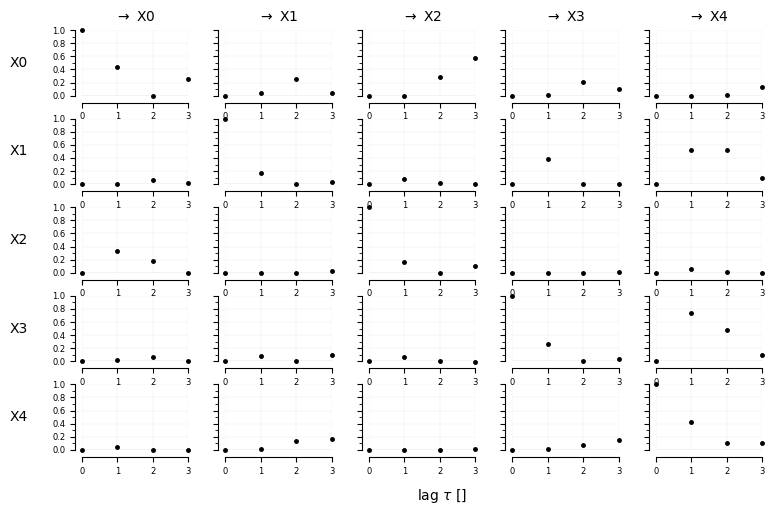

In [35]:
from causalts.cedar import run_cedar

res_cedar = run_cedar(
    df=df1,
    ci_test=ci_test,
    max_lag=data1["max_lag"],
    lag_method="dcor",
    alpha_cond1=0.01,
    alpha_cond2=0.01,
    normalize="minmax",
    verbose=False,
)
res_cedar.plot_lag_importance(
    x_base=1, show_gridlines=True,
    maximum=1, minimum=0,
    figsize=(8, 5),
)
plt.show()

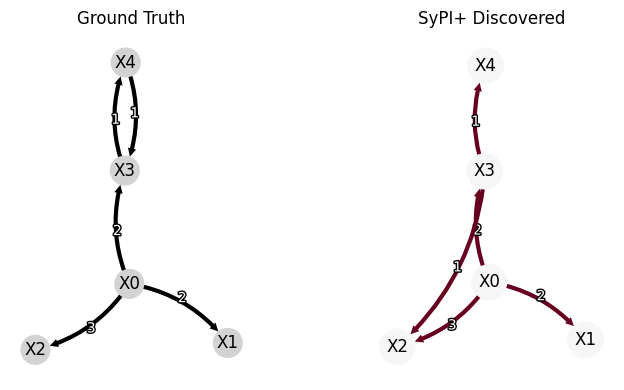

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
pos = tp.plot_graph(
    gt1, var_names=names1,
    arrow_linewidth=3, show_colorbar=False,
    fig_ax=(fig, axes[0]),
    return_pos=True,
)
axes[0].set_title("Ground Truth")
res_cedar.plot(
    node_pos=pos[2],
    fig_ax=(fig, axes[1]),
    node_size=0.25, arrow_linewidth=3,
)
axes[1].set_title("CEDAR Discovered")
plt.tight_layout()
plt.show()

## 13. Customization Reference

Fine-tune the visual appearance.

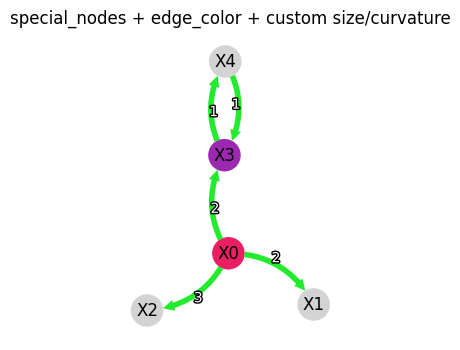

In [41]:
# special_nodes for manual node coloring
tp.plot_graph(
    gt1, var_names=names1,
    special_nodes={
        (names1[0], 0): "#E91E63",
        (names1[3], 0): "#9C27B0",
    },
    edge_color="#22EA2C",
    node_size=0.25,
    arrow_linewidth=4,
    curved_radius=0.3,
    show_colorbar=False,
    figsize=(4, 4),
)
plt.title("special_nodes + edge_color + custom size/curvature")
plt.show()

Uncomment savefig lines above to export


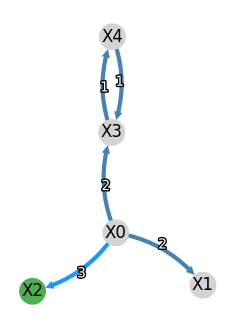

In [42]:
# Saving figures
fig, ax = tp.plot_graph(
    gt1, var_names=names1,
    edge_color="steelblue",
    target_node=names1[2],
    figsize=(4, 4),
)
# fig.savefig("my_graph.png", dpi=300, bbox_inches="tight")
# fig.savefig("my_graph.pdf", bbox_inches="tight")
print("Uncomment savefig lines above to export")
plt.show()